# API: Application programming interface
An API is a set of rules and tools that allows different software applications to communicate with each other.

So, considering python as one sort of the software, allows it to talk to any other software and extract the sort of data.

Many companies obtaining business of model of Data As Services sells the API as thier key product. 


# A. Obtaining Share Price: A popular Yahoo Finance API

**Step 1: Import yahoo finance** 

!pip install yfinance

if not installed, Please install using pip

MacBook will execute the following pip command

$ pip install yfinance



In [ ]:
'''Import the Yahooo finance library and pandas'''

import yfinance as yf
import pandas as pd



**Step 2: TICKER**

Every Stocks listed in NYSE and NASDAQ has its own ticker. 

we wee need to both identify stocks ticker and than fetch it into the yf ticker object

In [ ]:


# Define ticker symbol for Google (Alphabet)
ticker = "GOOGL"

# Create a Ticker object
goog = yf.Ticker(ticker)

**Step 3: extracting data**

using history function of the yahoo finance, we are ready for extracting the data. 

Two Arguments are necessart

1. Range of Date

2. interval at which we need a data. Our case is daily.

In [ ]:
'''Date:  from 2024-01-01 to 2024-11-01'''
'''Interval: daily data'''
data = goog.history(start="2024-01-01", end="2024-11-01", interval="1d")



In [6]:
# Print the first few rows
print(data.head())



                                 Open        High         Low       Close  \
Date                                                                        
2024-01-02 00:00:00-05:00  137.600958  138.494788  135.545130  137.223557   
2024-01-03 00:00:00-05:00  136.309840  138.673542  136.141007  137.968399   
2024-01-04 00:00:00-05:00  137.471843  138.206780  135.416030  135.455750   
2024-01-05 00:00:00-05:00  135.813280  136.220475  134.224234  134.800262   
2024-01-08 00:00:00-05:00  135.356426  138.057795  135.326633  137.888962   

                             Volume  Dividends  Stock Splits  
Date                                                          
2024-01-02 00:00:00-05:00  23711200        0.0           0.0  
2024-01-03 00:00:00-05:00  24212100        0.0           0.0  
2024-01-04 00:00:00-05:00  27137700        0.0           0.0  
2024-01-05 00:00:00-05:00  22513900        0.0           0.0  
2024-01-08 00:00:00-05:00  21404000        0.0           0.0  


** Step 4: Kind of Price**
The stock price can be of different level. Like, opening price is price which appear at beggining trading on a particular daya

closing price is last recorded share price on a particular day.

Depending upon the analytics, we obatain either open or closing price.

In [7]:
# Extract only the closing price column
close_prices = data["Close"]

# If you want, convert to a DataFrame with date as a column
df_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)

print(df_close.head())

                       Date       Close
0 2024-01-02 00:00:00-05:00  137.223557
1 2024-01-03 00:00:00-05:00  137.968399
2 2024-01-04 00:00:00-05:00  135.455750
3 2024-01-05 00:00:00-05:00  134.800262
4 2024-01-08 00:00:00-05:00  137.888962


In [8]:
df_close.to_csv("google_close_prices.csv", index=False)

In [9]:
'''Load google close price'''

df_google = pd.read_csv("google_close_prices.csv")
df_google.head()

,Date,Close
0,2024-01-02 00:00:00-05:00,137.223557
1,2024-01-03 00:00:00-05:00,137.968399
2,2024-01-04 00:00:00-05:00,135.455750
3,2024-01-05 00:00:00-05:00,134.800262
4,2024-01-08 00:00:00-05:00,137.888962


C:\Users\AL-MALAK\AppData\Local\Temp\ipykernel_10652\3951954986.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_google['Date'] = pd.to_datetime(df_google['Date'])


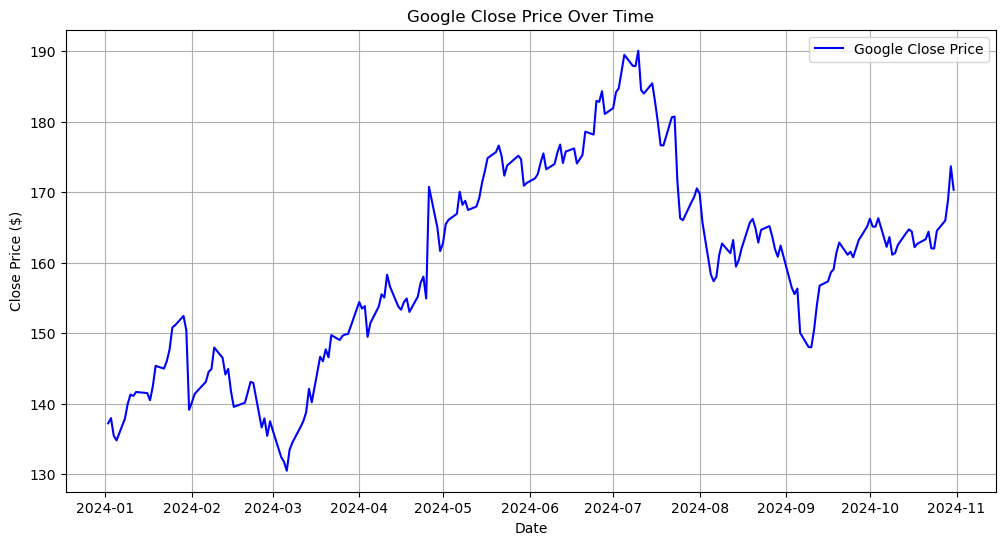

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert 'Date' column to datetime
df_google['Date'] = pd.to_datetime(df_google['Date'])

# Set 'Date' as the index (optional but makes plotting easier)
df_google.set_index('Date', inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df_google.index, df_google['Close'], color='blue', label='Google Close Price')
plt.title('Google Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

# Obtaining price on mutliple stocks

In [16]:
import yfinance as yf
import pandas as pd

# List of ticker symbols
tickers = ["GOOGL", "AAPL", "MSFT"]  # Google, Apple, Microsoft

# Download historical daily data for all tickers
# Specify period (e.g., 2024-01-01 to 2024-11-01)
data = yf.download(tickers, start="2024-01-01", end="2024-11-01", interval="1d")

# Print first few rows
print(data.head())



[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker            AAPL       GOOGL        MSFT        AAPL       GOOGL   
Date                                                                     
2024-01-02  183.903214  137.223557  365.421600  186.677021  138.494788   
2024-01-03  182.526230  137.968399  365.155609  184.140985  138.673542   
2024-01-04  180.208145  135.455750  362.534668  181.377098  138.206780   
2024-01-05  179.484940  134.800262  362.347473  181.050159  136.220475   
2024-01-08  183.823975  137.888962  369.185486  183.863609  138.057795   

Price                          Low                                Open  \
Ticker            MSFT        AAPL       GOOGL        MSFT        AAPL   
Date                                                                     
2024-01-02  370.377704  182.169586  135.545130  361.381827  185.399081   
2024-01-03  367.776535  181.713894  136.141007  363.096316  182.496512   
2024-01-04  367.618867  179.187783  1

In [18]:
# Extract closing prices only
close_prices = data["Close"].copy()

# Remove top-level name if present
close_prices.columns.name = None

print(close_prices.head())


                  AAPL       GOOGL        MSFT
Date                                          
2024-01-02  183.903214  137.223557  365.421600
2024-01-03  182.526230  137.968399  365.155609
2024-01-04  180.208145  135.455750  362.534668
2024-01-05  179.484940  134.800262  362.347473
2024-01-08  183.823975  137.888962  369.185486


In [20]:
close_prices.to_csv("multiple_stocks_timesries.csv", index=True)

# Visulizing 

In [11]:
df_multiple = pd.read_csv("multiple_stocks_timesries.csv")
df_multiple.head()

,Date,AAPL,GOOGL,MSFT
0,2024-01-02,183.903214,137.223557,365.421600
1,2024-01-03,182.526230,137.968399,365.155609
2,2024-01-04,180.208145,135.455750,362.534668
3,2024-01-05,179.484940,134.800262,362.347473
4,2024-01-08,183.823975,137.888962,369.185486


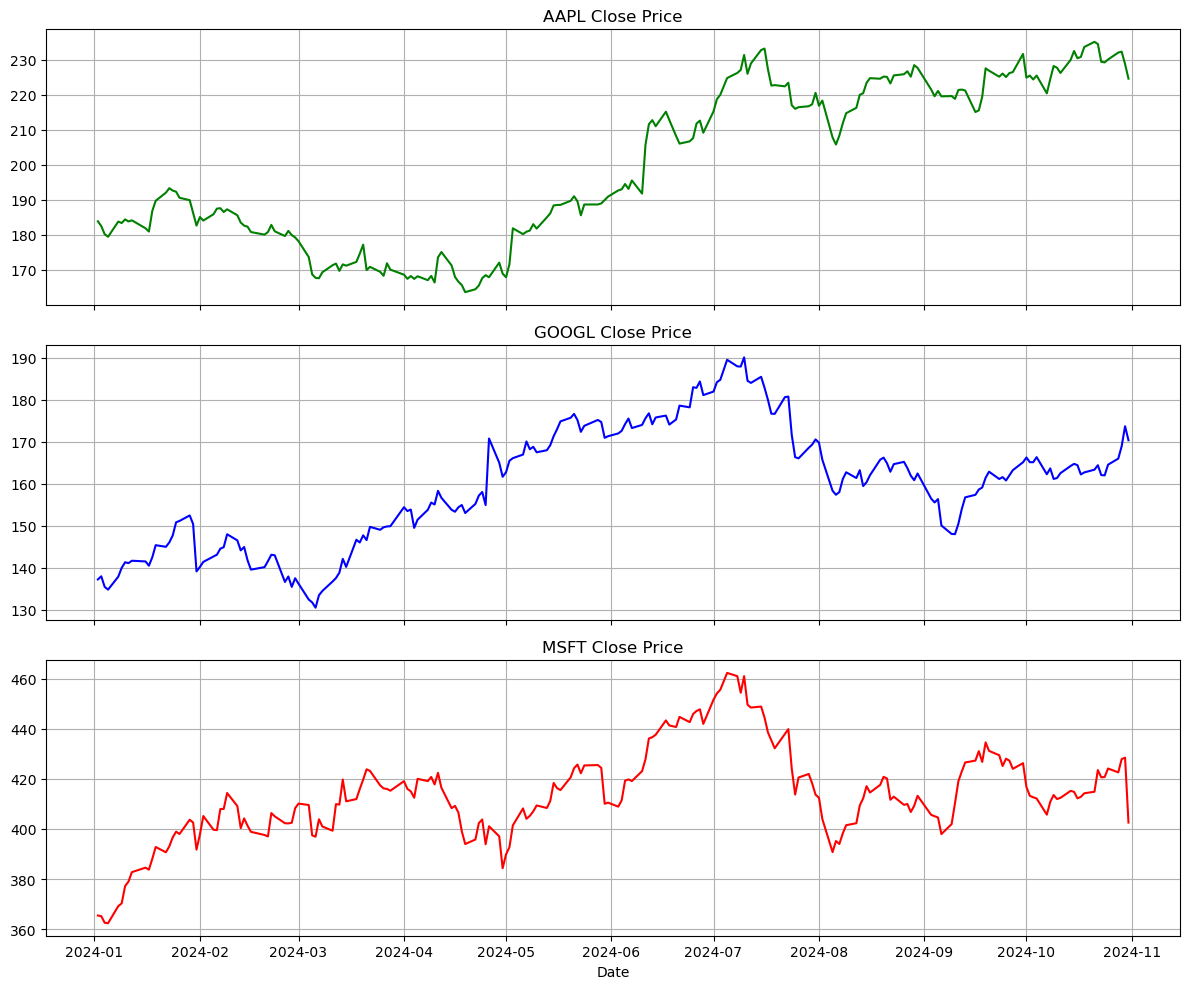

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


# Convert 'Date' column to datetime
df_multiple['Date'] = pd.to_datetime(df_multiple['Date'])

# Create subplots: 3 rows, 1 column, shared x-axis
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12,10), sharex=True)

# Plot each stock in its own subplot
axes[0].plot(df_multiple['Date'], df_multiple['AAPL'], color='green')
axes[0].set_title('AAPL Close Price')
axes[0].grid(True)

axes[1].plot(df_multiple['Date'], df_multiple['GOOGL'], color='blue')
axes[1].set_title('GOOGL Close Price')
axes[1].grid(True)

axes[2].plot(df_multiple['Date'], df_multiple['MSFT'], color='red')
axes[2].set_title('MSFT Close Price')
axes[2].grid(True)
axes[2].set_xlabel('Date')

# Adjust spacing
plt.tight_layout()
plt.show()


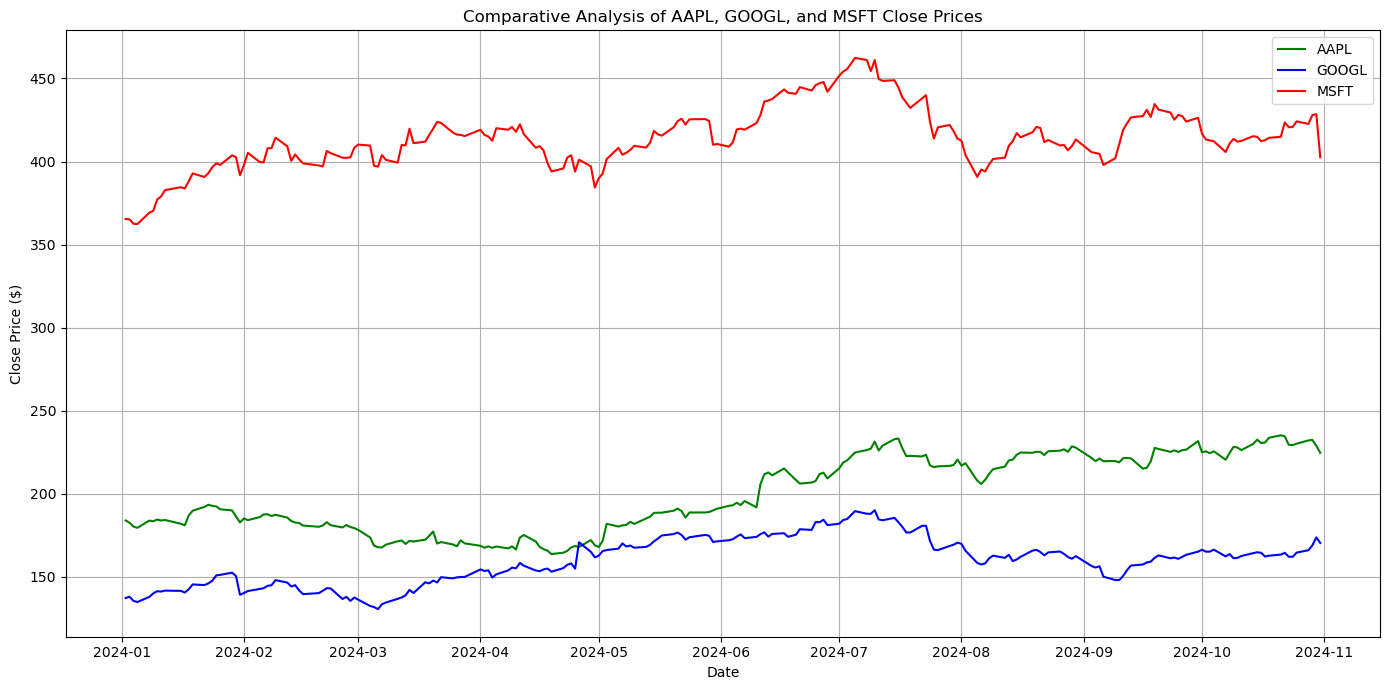

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_multiple = pd.read_csv("multiple_stocks_timesries.csv")

# Convert 'Date' column to datetime
df_multiple['Date'] = pd.to_datetime(df_multiple['Date'])

# Plot all three stocks in one figure
plt.figure(figsize=(14,7))
plt.plot(df_multiple['Date'], df_multiple['AAPL'], label='AAPL', color='green')
plt.plot(df_multiple['Date'], df_multiple['GOOGL'], label='GOOGL', color='blue')
plt.plot(df_multiple['Date'], df_multiple['MSFT'], label='MSFT', color='red')

# Titles and labels
plt.title('Comparative Analysis of AAPL, GOOGL, and MSFT Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


# Panel Data Analytics

In [19]:
# Optional: convert to long format (Date, Ticker, Close)
df_close_long = close_prices.reset_index().melt(id_vars="Date", var_name="Ticker", value_name="Close")
print(df_close_long.head())

        Date Ticker       Close
0 2024-01-02   AAPL  183.903214
1 2024-01-03   AAPL  182.526230
2 2024-01-04   AAPL  180.208145
3 2024-01-05   AAPL  179.484940
4 2024-01-08   AAPL  183.823975


In [22]:
df_close_long.to_csv("multiple_stocks_prices_panel.csv", index=False)

# B. News API:

A powerful API to collect the news headline

In [ ]:
import requests
from datetime import datetime

# Your NewsAPI key (register free at https://newsapi.org/)
api_key = ""

'''PUT YOUR NEWSAPI KEY HERE'''

# KEYWORDS
'''q=apple. however, you can put any other keyword to search for news articles.'''


In [ ]:
# Corrected URL
url = (
    f"https://newsapi.org/v2/everything?"
    f"q=apple&from=2025-11-21&to=2025-11-21&sortBy=popularity&apiKey={api_key}"
)


response = requests.get(url)
data = response.json()

articles = data.get("articles", [])
for i, article in enumerate(articles[:5], start=1):
    print(f"{i}. {article['title']} ({article['source']['name']})")


1. Apple’s new limited edition iPhone grip is all about accessibility (The Verge)
2. AirDropping stuff from a Pixel phone rules so much (The Verge)
3. Apple’s cheapest iPad is already $70 off for Black Friday (The Verge)
4. AI agents are invading your PC (The Verge)
5. The new silicon valley (literally) (The Verge)


In [45]:
# Extract articles
articles = data.get("articles", [])

# Create DataFrame
df_articles = pd.DataFrame([{
    "Title": article['title'],
    "Source": article['source']['name'],
    "Description": article['description'],
    "URL": article['url'],
    "PublishedAt": datetime.strptime(article['publishedAt'], "%Y-%m-%dT%H:%M:%SZ")
} for article in articles])

# Show first 5 articles
pd.set_option("display.max_colwidth", None)  # show full text
print(df_articles.head())

                                                                Title  \
0  Apple’s new limited edition iPhone grip is all about accessibility   
1                  AirDropping stuff from a Pixel phone rules so much   
2           Apple’s cheapest iPad is already $70 off for Black Friday   
3                                      AI agents are invading your PC   
4                                  The new silicon valley (literally)   

      Source  \
0  The Verge   
1  The Verge   
2  The Verge   
3  The Verge   
4  The Verge   

                                                                                                                                                                                                                                                            Description  \
0  Apple has partnered with artist and designer Bailey Hikawa on a new MagSafe iPhone grip “designed with accessibility in mind from the ground up.” The $69.95 Hikawa Phone Grip & Stand is availabl

In [48]:
df_articles.head(2)

,Title,Source,Description,URL,PublishedAt
0,Apple’s new limited edition iPhone grip is all about accessibility,The Verge,"Apple has partnered with artist and designer Bailey Hikawa on a new MagSafe iPhone grip “designed with accessibility in mind from the ground up.” The $69.95 Hikawa Phone Grip & Stand is available from the Apple Store now, but is listed as a limited edition. T…",https://www.theverge.com/news/826081/apple-hikawa-iphone-grip-stand-accessibility-limited-edition,2025-11-21 12:54:33
1,AirDropping stuff from a Pixel phone rules so much,The Verge,"It's pretty rare when a cool new gadget feature gets announced that you can try right away on your own devices. But that's exactly what happened yesterday when, out of the blue, Google announced it had engineered a way to bring AirDrop interoperability to Pix…",https://www.theverge.com/tech/825696/pixel-10-pro-airdrop-quick-share-hands-on,2025-11-21 11:11:42


In [49]:
df_articles.to_csv("apple_news_nov21_2025.csv", index=False)

# FULL High-end code: Trump

In [ ]:
import requests
import csv
import time

# -----------------------------
# Configuration
# -----------------------------
API_KEY = ""  # Replace with your NewsAPI key
QUERY = "trump"
FROM_DATE = "2025-11-21"  # start date
TO_DATE = "2025-11-22"    # end date
LANGUAGE = "en"
PAGE_SIZE = 100            # max per request
CSV_FILE = "trump_articles.csv"

# -----------------------------
# Fetch articles function
# -----------------------------
def fetch_articles(page=1):
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": QUERY,
        "from": FROM_DATE,
        "to": TO_DATE,
        "language": LANGUAGE,
        "sortBy": "publishedAt",
        "pageSize": PAGE_SIZE,
        "page": page,
        "apiKey": API_KEY
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Error fetching page {page}: {response.status_code} - {response.text}")
        return None
    return response.json()

# -----------------------------
# Save articles to CSV
# -----------------------------
def save_to_csv(articles, filename):
    keys = ["source", "author", "title", "description", "url", "publishedAt", "content"]
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        for article in articles:
            row = {
                "source": article["source"]["name"],
                "author": article.get("author"),
                "title": article.get("title"),
                "description": article.get("description"),
                "url": article.get("url"),
                "publishedAt": article.get("publishedAt"),
                "content": article.get("content")
            }
            writer.writerow(row)

# -----------------------------
# Main script
# -----------------------------
all_articles = []
page = 1

while True:
    data = fetch_articles(page)
    if data is None:
        break
    articles = data.get("articles", [])
    if not articles:
        break

    all_articles.extend(articles)
    print(f"Fetched page {page}, total articles so far: {len(all_articles)}")

    # Stop if we've fetched all articles or reached 100 pages (API limit)
    total_results = data.get("totalResults", 0)
    if len(all_articles) >= total_results or page >= 100:
        break

    page += 1
    time.sleep(1)  # avoid hitting rate limits

# Save all articles to CSV
save_to_csv(all_articles, CSV_FILE)
print(f"Saved {len(all_articles)} articles to {CSV_FILE}")


Fetched page 1, total articles so far: 79
Error fetching page 2: 426 - {"status":"error","code":"maximumResultsReached","message":"You have requested too many results. Developer accounts are limited to a max of 100 results. You are trying to request results 100 to 200. Please upgrade to a paid plan if you need more results."}
Saved 79 articles to trump_articles.csv


In [6]:
import pandas as pd
df_turmp = pd.read_csv("trump_articles.csv")
df_turmp.head()

,source,author,title,description,url,publishedAt,content
0,TheJournal.ie,Eoghan Dalton,Row between Trump and G20 hosts South Africa f...,US attendance at the G20 remains up in the air.,https://www.thejournal.ie/g20-trump-south-afri...,2025-11-21T13:34:20Z,A ROW BETWEEN the Trump administration and Sou...
1,Slashdot.org,feedfeeder,Trump Attacks Leave U.S. Cybersecurity Agencie...,Weve noted time and time again that Trumps att...,https://slashdot.org/firehose.pl?op=view&amp;i...,2025-11-21T13:33:09Z,The Fine Print: The following comments are own...
2,CBS News,CBS News,White House slams Democrats in video that prom...,The White House says President Trump does not ...,https://www.cbsnews.com/video/white-house-slam...,2025-11-21T13:33:00Z,Copyright ©2025 CBS Interactive Inc. All right...
3,The Times of India,TOI Education,Student visas under scrutiny: A detailed look ...,"In a proactive move, American educational inst...",https://timesofindia.indiatimes.com/education/...,2025-11-21T13:32:14Z,<ul><li>News</li>\r\n<li>Education News</li>\r...
4,Al Jazeera English,Priyanka Shankar,Why has Trump blasted US Democrats for ‘sediti...,Six Democratic Congress members call on the US...,https://www.aljazeera.com/news/2025/11/21/why-...,2025-11-21T13:30:43Z,United States President Donald Trump has accus...


# COIN Geko

In [ ]:
import requests
import pandas as pd
from datetime import datetime

# --------- CONFIGURATION ---------
api_key = ""  # Replace with your CoinGecko API key if required (not always needed for public endpoints)

# --------- FETCH HISTORICAL DATA ---------
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {
    "vs_currency": "pln",
    "days": "30"  # last 30 days
}
headers = {"x-cg-demo-api-key": api_key}

response = requests.get(url, params=params, headers=headers)

# --------- PROCESS DATA ---------
data = response.json()
prices = data["prices"]  # list of [timestamp, price] pairs

# Convert to DataFrame
df = pd.DataFrame(prices, columns=["timestamp_ms", "btc_pln"])
df["timestamp"] = pd.to_datetime(df["timestamp_ms"], unit='ms')
df = df[["timestamp", "btc_pln"]]  # reorder columns

# --------- SAVE CSV ---------
df.to_csv("bitcoin_price_pln.csv", index=False)

print(f"Saved {len(df)} historical BTC prices to bitcoin_price_pln.csv")


Saved 721 historical BTC prices to bitcoin_price_pln.csv


In [23]:
df_crypto = pd.read_csv("bitcoin_price_pln.csv")
df_crypto.head()

,timestamp,btc_pln
0,2025-10-23 15:01:25.576,399122.510788
1,2025-10-23 16:01:56.678,400717.910829
2,2025-10-23 17:00:32.266,401708.953264
3,2025-10-23 18:01:46.415,405068.602753
4,2025-10-23 19:01:05.225,402599.934640


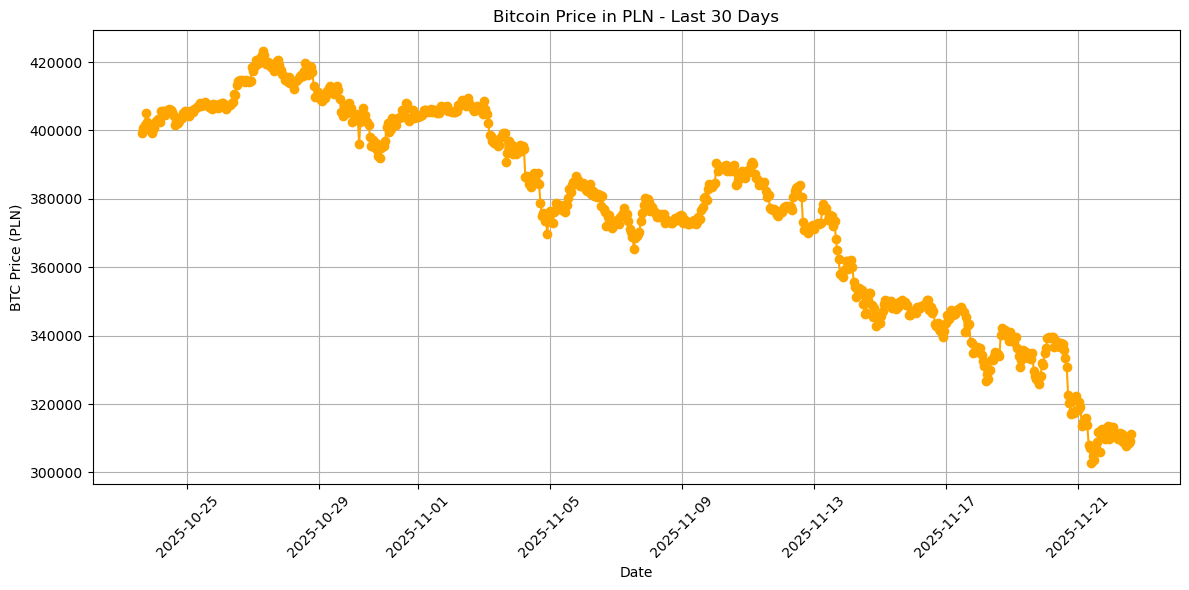

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# --------- ENSURE TIMESTAMP IS DATETIME ---------
df_crypto['timestamp'] = pd.to_datetime(df_crypto['timestamp'])
df_crypto.sort_values('timestamp', inplace=True)

# --------- PLOT LINE CHART ---------
plt.figure(figsize=(12, 6))
plt.plot(df_crypto['timestamp'], df_crypto['btc_pln'], marker='o', linestyle='-', color='orange')
plt.title("Bitcoin Price in PLN - Last 30 Days")
plt.xlabel("Date")
plt.ylabel("BTC Price (PLN)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import requests
import pandas as pd

# --------- CONFIGURATION ---------
api_key = ""  # Replace with your CoinGecko API key if required (not always needed for public endpoints)

# --------- FETCH DAILY HISTORICAL DATA ---------
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {
    "vs_currency": "pln",
    "days": "30",         # last 30 days
    "interval": "daily"   # daily prices
}
headers = {"x-cg-demo-api-key": api_key}

response = requests.get(url, params=params, headers=headers)
data = response.json()

# --------- PROCESS DATA ---------
prices = data["prices"]  # list of [timestamp_ms, price]
df = pd.DataFrame(prices, columns=["timestamp_ms", "btc_pln"])
df["date"] = pd.to_datetime(df["timestamp_ms"], unit='ms').dt.date
df = df[["date", "btc_pln"]]



In [26]:
df.to_csv("bitcoin_price_daily.csv", index=False)

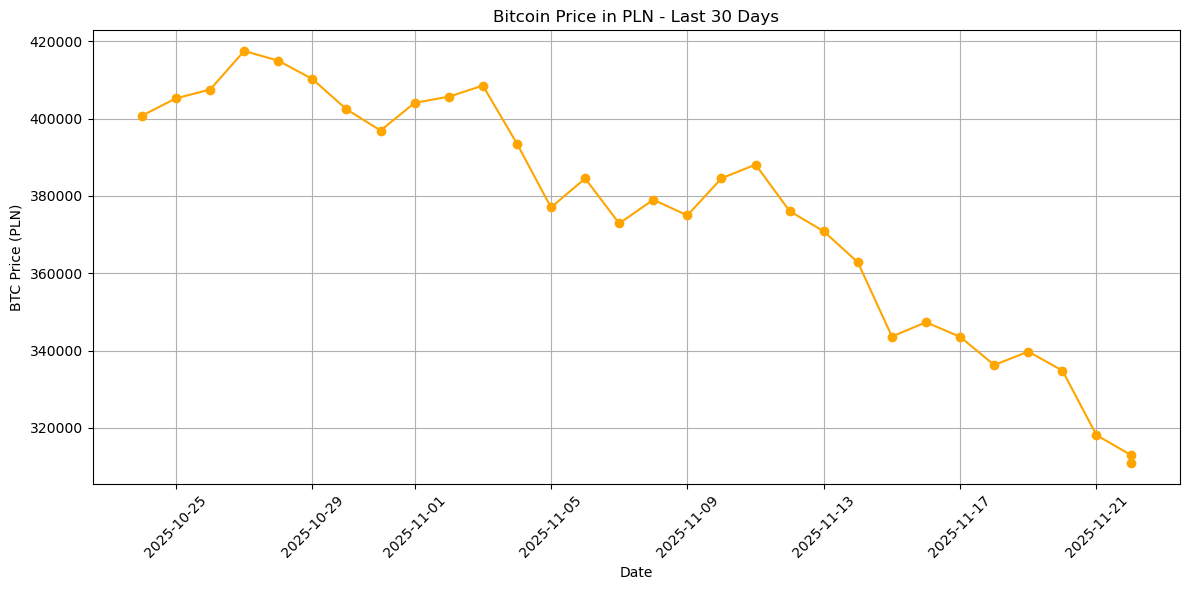

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# --------- LOAD CSV ---------
df_crypto = pd.read_csv("bitcoin_price_daily.csv")

# Ensure the 'date' column is recognized as datetime
df_crypto['date'] = pd.to_datetime(df_crypto['date'])

# --------- PLOT LINE CHART ---------
plt.figure(figsize=(12, 6))
plt.plot(df_crypto['date'], df_crypto['btc_pln'], marker='o', linestyle='-', color='orange')
plt.title("Bitcoin Price in PLN - Last 30 Days")
plt.xlabel("Date")
plt.ylabel("BTC Price (PLN)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
